# Análisis, Comparación y Optimización de Modelos de Salario

## 1\. Introducción y Configuración

Cargamos las librerías necesarias, incluyendo ahora `DecisionTreeRegressor` para la comparación y `RandomizedSearchCV` para la optimización automática.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib

# Modelos y Métricas
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Configuración visual
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

print(">>> Librerías cargadas. Listos para el análisis.")

>>> Librerías cargadas. Listos para el análisis.


-----

## 2\. Carga, Limpieza y EDA Visual

Antes de entrenar, vamos a observar los datos. Los salarios suelen tener distribuciones asimétricas (pocos ganan muchísimo).

**Objetivo Visual:**

  * **Histograma:** Ver la forma de la distribución.
  * **Boxplot:** Identificar visualmente los valores atípicos.

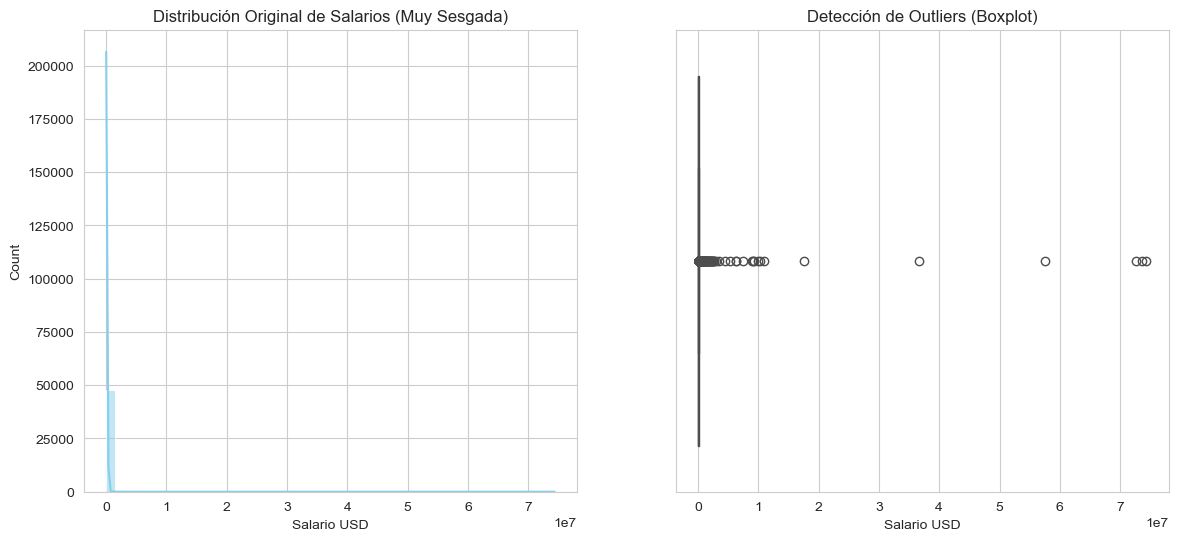

>>> Observación: La distribución está muy sesgada a la izquierda y hay outliers extremos.


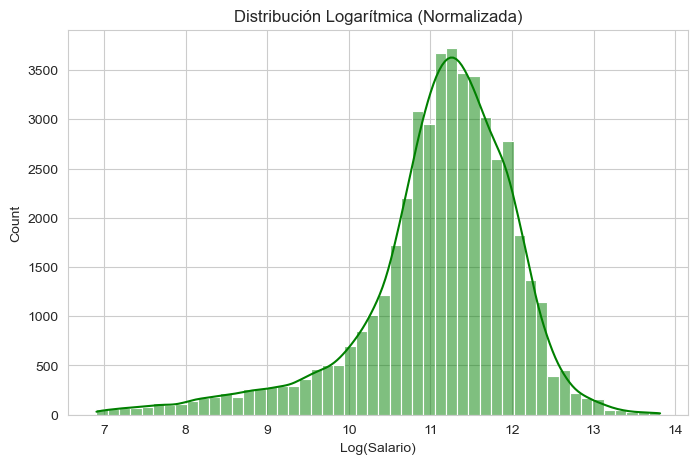

>>> Observación: Ahora la distribución se asemeja a una campana (Gaussiana), ideal para ML.


In [ ]:
# 1. Carga
file_path = "../../datasets/stack overflow/stack_overflow_2023.csv"
df = pd.read_csv(file_path)

# 2. Limpieza Básica
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df = df.dropna(subset=['ConvertedCompYearly', 'LanguageHaveWorkedWith'])

# --- ANÁLISIS VISUAL PREVIO ---
plt.figure(figsize=(14, 6))

# Gráfico A: Histograma Original (Con Outliers)
plt.subplot(1, 2, 1)
sns.histplot(df['ConvertedCompYearly'], bins=50, kde=True, color='skyblue')
plt.title('Distribución Original de Salarios')
plt.xlabel('Salario USD')

# Gráfico B: Boxplot Original
plt.subplot(1, 2, 2)
sns.boxplot(x=df['ConvertedCompYearly'], color='orange')
plt.title('Detección de Outliers (Boxplot)')
plt.xlabel('Salario USD')
plt.show()

print(">>> Observación: La distribución está muy sesgada a la izquierda y hay outliers extremos.")

# 3. Aplicación de Filtros y Transformación
# Filtro de Negocio: $1k a $1M
df = df[(df['ConvertedCompYearly'] >= 1000) & (df['ConvertedCompYearly'] <= 1000000)]
# Transformación Logarítmica (Para normalizar)
df['Log_ConvertedCompYearly'] = np.log1p(df['ConvertedCompYearly'])

# --- VISUALIZACIÓN POST-TRANSFORMACIÓN ---
plt.figure(figsize=(8, 5))
sns.histplot(df['Log_ConvertedCompYearly'], bins=50, kde=True, color='green')
plt.title('Distribución Logarítmica (Normalizada)')
plt.xlabel('Log(Salario)')
plt.show()
print(">>> Observación: Ahora la distribución se asemeja a una campana (Gaussiana), ideal para ML.")

-----

## 3\. Integración de Demanda LinkedIn

Aplicamos el mapeo del análisis externo que hicimos anteriormente de las ofertas de LinkedIn para crear las columnas de habilidades.

In [ ]:
# Lista de Habilidades de Alta Demanda
skills_demandadas = [
    'python', 'amazon web services', 'microsoft azure', 'go', 'oracle java',
    'c', 'r', 'javascript', 'linux', 'c++', 'git', 'c#', 'kubernetes',
    'react', 'docker', 'google cloud platform', 'tableau', 'nosql', 'unix',
    'node.js', 'servicenow', 'typescript', 'vmware', 'github', 'bash',
    'mysql', 'scala', 'spring boot', 'postgresql', 'mongodb', 'php', 'redis', 'sql'
]

mapeo_busqueda = {
    'amazon web services': 'aws', 'microsoft azure': 'azure', 'oracle java': 'java',
    'google cloud platform': 'google', 'bash': 'bash', 'c++': 'c++',
    'node.js': 'node', 'react': 'react', 'sql': 'sql'
}

cols_tech = ['LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith',
             'WebframeHaveWorkedWith', 'ToolsTechHaveWorkedWith', 'MiscTechHaveWorkedWith']
cols_existentes = [c for c in cols_tech if c in df.columns]
df['All_Skills_Soup'] = df[cols_existentes].fillna('').agg(';'.join, axis=1).str.lower()

# One-Hot Encoding Manual
print(">>> Generando features de habilidades...")
for skill in skills_demandadas:
    termino = mapeo_busqueda.get(skill, skill)
    col_name = f"Skill_{skill.replace(' ', '_').replace('.', '')}"
    df[col_name] = df['All_Skills_Soup'].apply(lambda x: 1 if termino in x else 0)

>>> Generando features de habilidades...


-----

## 4\. Procesamiento Demográfico y Limpieza Final

Preparamos las variables categóricas y eliminamos la variable `CompTotal` ya que solo muestra el salario sin convertirlo a la moneda estándar que estamos usando USD.

In [8]:
# Experiencia y Educación
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'].replace({'Less than 1 year': 0.5, 'More than 50 years': 50}), errors='coerce').fillna(5)
mapeo_edu = {'Something else': 0, 'Primary/elementary school': 1, 'Secondary school': 2, 'Some college': 3, 'Associate degree': 4, 'Bachelor’s degree': 5, 'Master’s degree': 6, 'Professional degree': 7}
df['EdLevel_Code'] = df['EdLevel'].map(mapeo_edu).fillna(5)

# País y Rol (Top 15 + One Hot)
for col in ['Country', 'DevType']:
    df[col] = df[col].fillna('Other')
    top_val = df[col].value_counts().head(15).index
    df[f"{col}_Grouped"] = df[col].apply(lambda x: x if x in top_val else 'Other')
    df = pd.concat([df, pd.get_dummies(df[f"{col}_Grouped"], prefix=('Role' if col == 'DevType' else 'Country'), dtype=int)], axis=1)

# Selección Final (X e y)
cols_prohibidas = ['CompTotal', 'CompFreq', 'ConvertedCompYearly', 'Log_ConvertedCompYearly',
                   'LanguageHaveWorkedWith', 'All_Skills_Soup', 'Country', 'Country_Grouped',
                   'DevType', 'DevType_Grouped', 'EdLevel', 'YearsCode', 'ResponseId', 'WorkExp', 'Currency']

X = df.drop(columns=[c for c in cols_prohibidas if c in df.columns]).select_dtypes(include=[np.number])
y = df['Log_ConvertedCompYearly']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f">>> Dataset listo. Features: {X.shape[1]}")

>>> Dataset listo. Features: 67


-----

## 5\. Comparación de Modelos (Benchmarking)

Vamos a probar tres enfoques distintos para ver cuál captura mejor la complejidad del mercado:

1.  **Regresión Lineal:** El estándar base. Asume relaciones simples.
2.  **Árbol de Decisión (Decision Tree):** Crea reglas tipo "Si sabe AWS \> entonces gana más". Tiende al sobreajuste (*overfitting*) si no se controla.
3.  **XGBoost (Gradient Boosting):** Una colección de cientos de árboles que corrigen sus errores entre sí.

<!-- end list -->

In [9]:
# Definir los candidatos
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(max_depth=10, random_state=42),
    "XGBoost Base": xgb.XGBRegressor(n_estimators=100, random_state=42)
}

resultados = []

print(">>> Iniciando comparativa de modelos...")

for nombre, modelo in modelos.items():
    # Entrenar
    modelo.fit(X_train, y_train)

    # Predecir
    y_pred_log = modelo.predict(X_test)

    # Métricas
    r2 = r2_score(y_test, y_pred_log)
    mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log))

    resultados.append({"Modelo": nombre, "R2": r2, "MAE (USD)": mae})

# Mostrar Tabla Comparativa
df_resultados = pd.DataFrame(resultados).sort_values(by="R2", ascending=False)
print(df_resultados)

# Selección del ganador
mejor_modelo_nombre = df_resultados.iloc[0]['Modelo']
print(f"\n>>> El ganador es: {mejor_modelo_nombre}")

>>> Iniciando comparativa de modelos...
              Modelo        R2     MAE (USD)
2       XGBoost Base  0.537565  32219.207477
0   Regresión Lineal  0.481338  35542.567449
1  Árbol de Decisión  0.456866  35255.117185

>>> El ganador es: XGBoost Base


-----

## 6\. Optimización de Hiperparámetros (Tuning)

Como XGBoost** ganó, vamos a mejorar su configuración por defecto usando `RandomizedSearchCV`. Esto busca combinaciones aleatorias de parámetros para encontrar la mejor configuración sin tardar horas.

**Parámetros a optimizar:**

  * `n_estimators`: Número de árboles.
  * `learning_rate`: Qué tan rápido aprende (menor es más preciso pero lento).
  * `max_depth`: Profundidad de los árboles (complejidad).
  * `subsample`: Porcentaje de datos usados por árbol (evita overfitting).

<!-- end list -->

In [10]:
print(f">>> Iniciando Optimización para XGBoost...")

# 1. Grilla de Parámetros
param_dist = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [6, 8, 10],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# 2. Configurar Búsqueda Aleatoria (Más rápida que GridSearch)
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,        # Probar 10 combinaciones aleatorias
    scoring='r2',     # Optimizar R2
    cv=3,             # Validación cruzada de 3 pliegues
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 3. Ejecutar Búsqueda (Esto puede tardar unos minutos)
random_search.fit(X_train, y_train)

# 4. Mejores Parámetros
print(f"\n>>> Mejores Parámetros encontrados: {random_search.best_params_}")
best_xgb = random_search.best_estimator_

# 5. Evaluación Final del Modelo Optimizado
y_pred_opt = best_xgb.predict(X_test)
r2_opt = r2_score(y_test, y_pred_opt)
mae_opt = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_opt))

print(f"--- RENDIMIENTO DEFINITIVO ---")
print(f"R² Score: {r2_opt:.2%}")
print(f"MAE: ${mae_opt:,.2f} USD")

>>> Iniciando Optimización para XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

>>> Mejores Parámetros encontrados: {'subsample': 0.7, 'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
--- RENDIMIENTO DEFINITIVO ---
R² Score: 54.98%
MAE: $31,587.17 USD


-----

## 7\. Guardado Final

Exportamos el modelo campeón (el optimizado).

In [11]:
# Guardar Modelo Optimizado y Features
joblib.dump(best_xgb, 'modelo_salarial_xgb.pkl')
joblib.dump(X.columns.tolist(), 'model_features.pkl')

print(">>> Modelo optimizado guardado. ¡Listo para la Web!")

>>> Modelo optimizado guardado. ¡Listo para la Web!
